In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sc

In [2]:
def momento_resistente_secao_sem_cor(a_s: float, b_w: float, h: float, f_ck: float, f_yk: float = 500000, gamma_s: float = 1.00, gamma_c: float = 1.00) -> float:
    """
    Calcula o momento resistente para vigas de concreto armado.

    Args:
        a_s (float): Área da armadura longitudinal (mm²)
        b_w (float): Largura da seção transversal (mm)
        h (float): Altura total da seção transversal (mm)
        f_ck (float): Resistência característica à compressão do concreto (kPa)
        f_yk (float): Resistência característica do aço (kPa). Padrão: 500000
        gamma_s (float): Fator de segurança do aço. Padrão: 1.15
        gamma_c (float): Fator de segurança do concreto. Padrão: 1.40

    Returns:
        m_rd: valor do momento resistente limite utilizando armadura simples (N.mm)
    """

    """
    Transforms a vector of random variables from the X space to the Y space.

    :param x: Random variables in the X space.
    :param dneq1: D^-1 matrix.
    :param mu_neq: Mean matrix.
    
    :return: output [0] = Probability of failure values for each indicator function, 
                output[1] = beta_df: Reliability index values for each indicator function.
    """

    # Temporary conversion of f_ck to MPa to determine coefficients
    f_ck /= 1E3  # in MPa

    if f_ck > 50:
        lambdaa = 0.80 - ((f_ck - 50) / 400)
        alpha_c = (1.00 - ((f_ck - 50) / 200)) * 0.85
    else:
        lambdaa = 0.80
        alpha_c = 0.85

    f_ck *= 1E3
    # Convert f_ck back to kPa and calculate f_cd (design compressive strength)
    f_cd = f_ck / gamma_c

    # Effective depth of the section
    d = h * 0.90

    # Design yield strength of steel
    f_yd = f_yk / gamma_s

    # Depth of the neutral axis
    x = (a_s * f_yd) / (f_cd * b_w * alpha_c * lambdaa)

    # Calculation of the ultimate resisting moment
    m_rd = a_s * f_yd * (d - 0.5 * lambdaa * x)

    return m_rd

def beta_equation(pf: float) -> float:
    """
    Calculates the reliability index value for a given probability of failure (pf), using the inverse cumulative distribution function (ICDF) of the standard normal distribution.

    :param pf: Probability of failure (pf).

    :return: Reliability index (β).
    """

    return -sc.stats.norm.ppf(pf)

In [3]:
n = 75000
m_rd = 29.36
b_w = 0.20
h = 0.50
n_b = 3
phi = 8/1000
a_s = n_b * (np.pi * (phi ** 2) / 4)
f_ck = 25000
f_yk = 500000

chi_samples = np.random.uniform(0.1, 0.6, 500)
# chi_samples = [0.1]
# print(chi_samples)
beta = []
for chi in chi_samples:
    gamma_g = 1.40
    gamma_q = 1.40
    den_g = gamma_g + gamma_q*chi/(1-chi)
    den_q = gamma_g*(1-chi)/chi + gamma_q
    # print(f"chi: {chi}, den_g: {den_g}, den_q: {den_q}")
    m_gk = m_rd/den_g
    m_qk = m_rd/den_q

    f_ck_sample = np.random.normal(1.22 * f_ck, 0.15 * 1.22 *f_ck, n)
    f_yk_sample = np.random.normal(1.22 * f_yk, 0.04 * 1.22 * f_yk, n)
    m_gk_sample = np.random.normal(1.06 * m_gk, 0.12 * 1.06 * m_gk, n)
    m_qk_sample = np.random.gumbel(0.21 * m_qk, 0.76 * 0.21 * m_qk, n)
    erro_r_sample = np.random.normal(1, 0.05, n)
    erro_s_sample = np.random.normal(1, 0.05, n)

    df = pd.DataFrame({
        'f_ck': f_ck_sample,
        'f_yk': f_yk_sample,
        'm_gk': m_gk_sample,
        'm_qk': m_qk_sample,
        'erro_r': erro_r_sample,
        'erro_s': erro_s_sample
    })

    df['m_sd'] = df['m_gk'] + df['m_qk']
    m_rd = []
    for i, r in df.iterrows():
        m_rd.append(momento_resistente_secao_sem_cor(a_s, b_w, h, r['f_ck'], f_yk=r['f_yk']))

    df['m_rd'] = m_rd
    df['g'] = df['m_rd'] * df['erro_r'] - df['m_sd'] * df['erro_s']
    df['i'] = np.where(df['g'] < 0, 1, 0)
    pf = sum(df['i']) / n
    beta.append(beta_equation(pf))

KeyboardInterrupt: 

In [ ]:
momento_resistente_secao_sem_cor(a_s, b_w, h, 25000, 500000, gamma_s=1.15, gamma_c=1.40)

28.79564883357598

In [ ]:
# chi_samples

In [ ]:
len(beta)

499

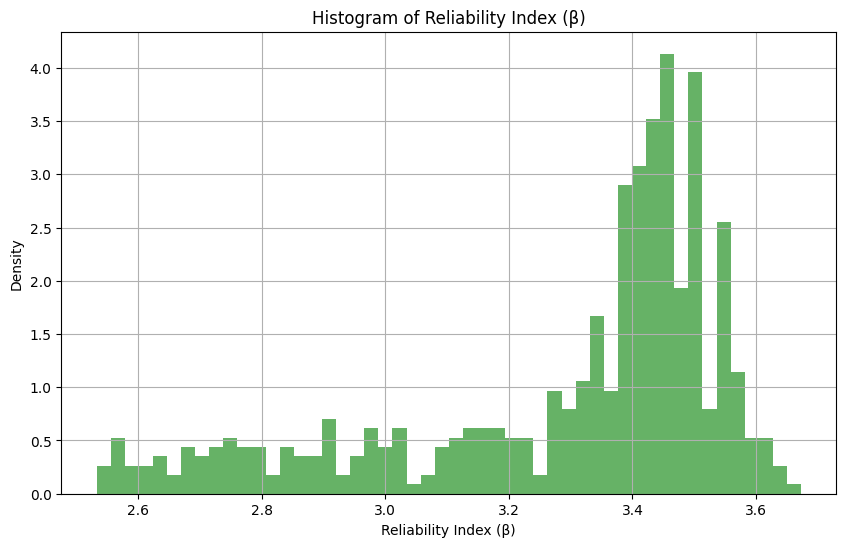

In [ ]:
# beta = m_qk_sample.copy()
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(beta, bins=50, density=True, alpha=0.6, color='g')
plt.title('Histogram of Reliability Index (β)')
plt.xlabel('Reliability Index (β)')
plt.ylabel('Density')
plt.grid(True)
plt.savefig('reliability_index_histogram.png')
plt.show()